In [90]:
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
from scipy.stats import beta

from src.train import train

see if VI can learn the skewness, shift, and scale

- start from the target that is exactly in the class; first implement the class in jax.
- then try skewed t
- then try banana and other targets



In [91]:
def uniform_sample_bright_side(d, latitude, key, n=1):
    """
    Sample uniformly from the bright side of a d-dimensional sphere.
    """
    key, subkey = jax.random.split(key)
    u = jax.random.uniform(subkey, shape=(n,))

    u = beta.cdf(latitude / 2, d/2, d/2) * u
    height = beta.ppf(u, d/2, d/2) * 2
    radius = jnp.sqrt(1 - (height - 1)**2)
    key, subkey = jax.random.split(key)
    x = jax.random.normal(subkey, (n, d))
    x = x / jnp.linalg.norm(x, axis=-1, keepdims=True) * radius[:, None]
    return jnp.concatenate([x, height[:, None]], axis=-1)

In [92]:
class SCP:
    def __init__(self, d, latitude):
        self.d = d
        self.latitude = latitude

    def transform_params(self, params):
        observer = params['observer']
        observer = observer / jnp.sqrt(1 + jnp.sum(observer**2)) * jnp.sqrt(1 - (1 - self.latitude)**2)
        scale = jnp.exp(params['scale'])
        shift = params['shift']
        return observer, shift, scale
    
    def inverse_transform_params(self, observer, shift, scale):
        observer = observer / jnp.sqrt(1 - (1 - self.latitude)**2)
        observer = observer / jnp.sqrt(1 - jnp.sum(observer**2) )
        return {'observer': observer, 
                'shift': shift, 
                'scale': jnp.log(scale)}

    def projection(self, params, x):
        observer, shift, scale = self.transform_params(params)
        y = (self.latitude * x[:, :-1] - x[:, -1:] * observer) / (self.latitude - x[:, -1:])
        return y * scale + shift
    
    def log_jacobian(self, params, y, x=None):
        observer, shift, scale = self.transform_params(params)
        if y is None:
            y = self.projection(params, x)
        y_hat = (y - shift) / scale

        _a = jnp.sum((y_hat - observer) ** 2) + self.latitude ** 2
        
        _b = 2 * ((jnp.dot(y_hat - observer, observer) - self.latitude * (self.latitude - 1)))
        
        _c = jnp.sum(observer ** 2) + self.latitude ** 2 - 2 * self.latitude

        Delta = _b ** 2 - 4 * _a * _c
        M = (-_b + jnp.sqrt(Delta)) / (2 * _a)
        
        d = self.d
        
        return d * jnp.log(scale / M) - jnp.log(self.latitude) + jnp.log(M * jnp.sum((y_hat - observer) ** 2) + jnp.dot(y_hat - observer, observer) + self.latitude - self.latitude**2 * (1 - M))

    def log_prob(self, params, y):
         return -self.log_jacobian(params, y)

    def sample(self, params, key, n=1):
        X = uniform_sample_bright_side(self.d, self.latitude, key, n=n)
        return self.projection(params, X)

In [93]:
d = 2
latitude = 1.5
scp = SCP(d, latitude=latitude)

Specify target density

In [94]:
target_params = scp.inverse_transform_params(jnp.array([0.7, -0.5]), jnp.zeros(d), 1.)

def target_logp(x):
    return scp.log_prob(target_params, x)

Visualize target distribution

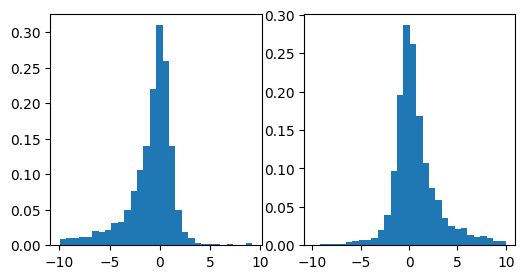

In [95]:
key = jax.random.key(0)
exact_samples = scp.sample(target_params, key, n=5000)

fig, ax = plt.subplots(1, 2, figsize=(6, 3))
ax[0].hist(exact_samples[abs(exact_samples[:, 0]) < 10 , 0], 30, density=True)
ax[1].hist(exact_samples[abs(exact_samples[:, 1]) < 10 , 1], 30, density=True)
plt.show()

Initialize parameters and samples

In [97]:
seed = 1
ntrain = 5000
X = uniform_sample_bright_side(d, latitude, jax.random.key(seed), n=ntrain)

params = {
    'observer': jnp.zeros(d),
    'shift': jnp.zeros(d),
    'scale': 0.
}

Define loss function as the reverse KL

In [98]:
@jax.jit
def loss_fn(params, X):
    Y = scp.projection(params, X)
    logp = jax.vmap(target_logp)(Y)
    logdet = jax.vmap(scp.log_jacobian, in_axes=(None, 0))(params, Y)
    return -jnp.mean(logdet + logp)

Training via Adam

In [99]:
opt_params, losses = train(lambda params: loss_fn(params, X), params, learning_rate=0.01, max_iter=1000)

Running for 1,000 iterations: 100%|██████████| 1000/1000 [00:00<00:00, 2855.87it/s]


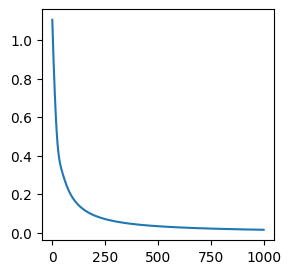

In [100]:
plt.figure(figsize=(3, 3))
plt.plot(losses)

In [107]:
scp.transform_params(opt_params), scp.transform_params(target_params)

((Array([ 0.66488034, -0.4753901 ], dtype=float32),
  Array([-0.0314632 , -0.00560353], dtype=float32),
  Array(0.94333524, dtype=float32)),
 (Array([ 0.7       , -0.49999997], dtype=float32),
  Array([0., 0.], dtype=float32),
  Array(1., dtype=float32, weak_type=True)))

In [102]:
transformed_samples = scp.projection(opt_params, X)

Visualize transformed samples with the learned parameters

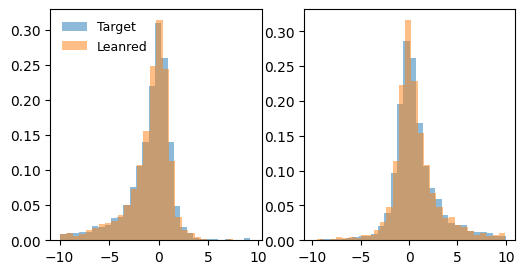

In [116]:
fig, ax = plt.subplots(1, 2, figsize=(6, 3))
ax[0].hist(exact_samples[abs(exact_samples[:, 0]) < 10 , 0], 30, density=True, alpha=.5, label='Target')
ax[0].hist(transformed_samples[abs(transformed_samples[:, 0]) < 10 , 0], 30, density=True, alpha=.5, label='Leanred')

ax[1].hist(exact_samples[abs(exact_samples[:, 1]) < 10 , 1], 30, density=True, alpha=.5)
ax[1].hist(transformed_samples[abs(transformed_samples[:, 1]) < 10 , 1], 30, density=True, alpha=.5)

ax[0].legend(loc='upper left', fontsize=9, frameon=False)
plt.show()

## Skewed $t$

In [291]:
import numpy as np
from scipy.stats import jf_skew_t #, skewcauchy

In [292]:
d = 2
a = np.array([1., 2.])
b = np.array([2., 1.])
target_skewt = jf_skew_t(a, b)

In [293]:
exact_samples = target_skewt.rvs((1000, d))

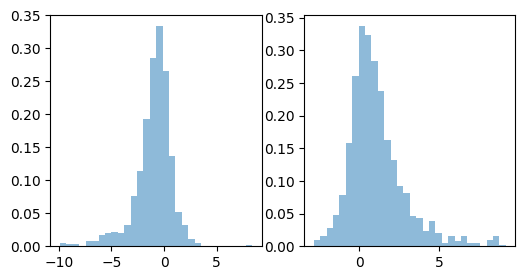

In [294]:
fig, ax = plt.subplots(1, 2, figsize=(6, 3))
ax[0].hist(exact_samples[abs(exact_samples[:, 0]) < 10 , 0], 30, density=True, alpha=.5)
ax[1].hist(exact_samples[abs(exact_samples[:, 1]) < 10 , 1], 30, density=True, alpha=.5)
plt.show()

In [295]:
x = exact_samples
tmp = (a + 0.5) * jnp.log(1 + x / jnp.sqrt(a + b + x**2)) + (b + .5) * jnp.log(1 - x / jnp.sqrt(a + b + x**2))

In [296]:
def target_logp(x):
    # return target_skewt.logpdf(x).sum(-1)
    logp = (a + 0.5) * jnp.log(1 + x / jnp.sqrt(a + b + x**2)) + (b + .5) * jnp.log(1 - x / jnp.sqrt(a + b + x**2))
    return logp.sum(-1)

In [297]:
seed = 4
ntrain = 5000
X = uniform_sample_bright_side(d, latitude, jax.random.key(seed), n=ntrain)

params = {
    'observer': jnp.zeros(d),
    'shift': jnp.zeros(d),
    'scale': 0.
}

@jax.jit
def loss_fn(params, X):
    Y = scp.projection(params, X)
    logp = jax.vmap(target_logp)(Y)
    logp = jnp.where(jnp.abs(logp) < 1e10, logp, jnp.nan)
    # logp = jnp.clip(logp, -1e10, 1e10)
    logdet = jax.vmap(scp.log_jacobian, in_axes=(None, 0))(params, Y)
    return -jnp.nanmean(logdet + logp)

In [298]:
jax.grad(loss_fn)(params, X)

{'observer': Array([-0.67933065,  0.544635  ], dtype=float32),
 'scale': Array(1.0929434, dtype=float32, weak_type=True),
 'shift': Array([ 0.4290835, -0.4118831], dtype=float32)}

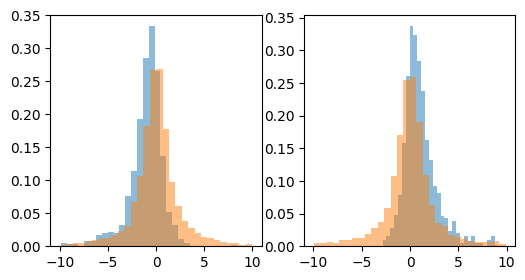

In [299]:
initial_samples = scp.projection(params, X)
fig, ax = plt.subplots(1, 2, figsize=(6, 3))
ax[0].hist(exact_samples[abs(exact_samples[:, 0]) < 10 , 0], 30, density=True, alpha=.5)
ax[0].hist(initial_samples[abs(initial_samples[:, 0]) < 10 , 0], 30, density=True, alpha=.5)
ax[1].hist(exact_samples[abs(exact_samples[:, 1]) < 10 , 1], 30, density=True, alpha=.5)
ax[1].hist(initial_samples[abs(initial_samples[:, 1]) < 10 , 1], 30, density=True, alpha=.5)
plt.show()

In [300]:
opt_params, losses = train(lambda params: loss_fn(params, X), params, learning_rate=0.01, max_iter=1000)

Running for 1,000 iterations: 100%|██████████| 1000/1000 [00:00<00:00, 5616.92it/s]


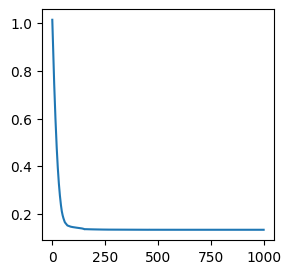

In [301]:
plt.figure(figsize=(3, 3))
plt.plot(losses)

In [302]:
scp.transform_params(opt_params)

(Array([ 0.5123873 , -0.38729987], dtype=float32),
 Array([-0.45301968,  0.5486884 ], dtype=float32),
 Array(0.6792087, dtype=float32))

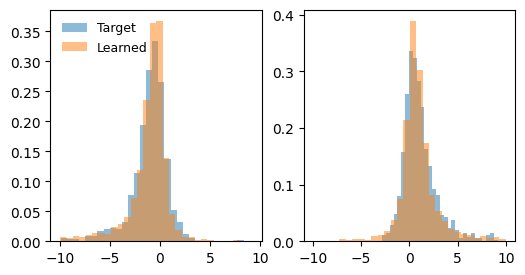

In [303]:
transformed_samples = scp.projection(opt_params, X)
fig, ax = plt.subplots(1, 2, figsize=(6, 3))
ax[0].hist(exact_samples[abs(exact_samples[:, 0]) < 10 , 0], 30, density=True, alpha=.5, label='Target')
ax[0].hist(transformed_samples[abs(transformed_samples[:, 0]) < 10 , 0], 30, density=True, alpha=.5, label='Learned')
ax[1].hist(exact_samples[abs(exact_samples[:, 1]) < 10 , 1], 30, density=True, alpha=.5, label='Target')
ax[1].hist(transformed_samples[abs(transformed_samples[:, 1]) < 10 , 1], 30, density=True, alpha=.5, label='Learned')
ax[0].legend(loc='upper left', fontsize=9, frameon=False)
plt.show()